In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../src"))

import scanpy as sc
from dmt import DyMoTree

adata = sc.read_h5ad('../../data/case/mmE/anndata/anndata.h5ad')
dmt = DyMoTree(adata=adata,
               k=40,
               progenitor='ICM',
               terminal=['EPI','PrE'],
               lineage_col='lineage',
               emb_key='emb',
               device='cuda',
               seed=42)

dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

Successfully loaded state: ICM, cells: 698
Successfully loaded state: EPI, cells: 49
Successfully loaded state: PrE, cells: 155
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'ICM' (Edges: 27222)
[*] Intra-state graph built for 'EPI' (Edges: 1911)
[*] Intra-state graph built for 'PrE' (Edges: 6045)
[*] Calculating composite similarity between progenitor 'ICM' and terminals ['EPI', 'PrE']...
[*] Inter-state graph built for 'EPI' (Edges: 10339)
[*] Inter-state graph built for 'PrE' (Edges: 48229)


In [2]:
dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-4},
              iter = {'formal':350,
                    'intra':100,
                    'lineage':350},
              sample_ratio = 256,
              alpha = 0)

:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for ICM ::


100%|██████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.36it/s, loss=0.72]


:: Do pre-train Graph encoder for EPI ::


100%|██████████████████████████████████████████████████| 100/100 [00:01<00:00, 89.64it/s, loss=0.98]


:: Do pre-train Graph encoder for PrE ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 350/350 : 100%|█████████████████████████████████| 350/350 [00:23<00:00, 14.95it/s, loss=0.501]


:: DyMoTree Training::


Iter: 350/350 : 100%|█████████████████████████████████| 350/350 [00:23<00:00, 15.02it/s, loss=0.788]

[2026-06-08 10:53:37] get fate space of ICM


<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

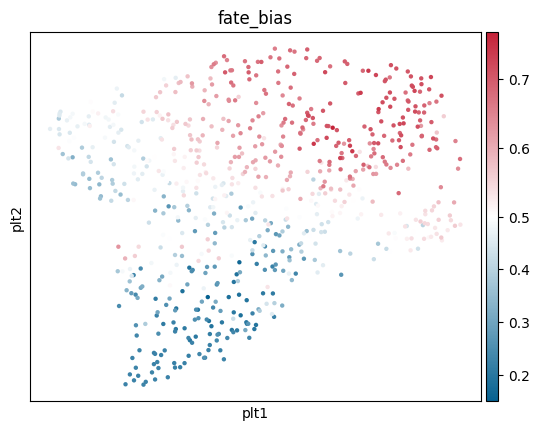

In [3]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)

progenitor = dmt.treedata.get_node('ICM',adata_object=True)
progenitor.obs['fate_bias'] = dmt.cal_fate_bias(progenitor.obs['EPI_fate'], progenitor.obs['PrE_fate'])
sc.pl.embedding(progenitor, basis='plt', color=['fate_bias'], show=False,cmap=custom_bwr,vcenter=0.5,size=40)


In [5]:
# find cell state
dmt.find_state(n_state=3,
               n_pca=5,
               n_diff=5,
               n_gene=10,
               method='spearman')

[2026-06-08 10:55:23] find cell state of ICM
[2026-06-08 10:55:23] Filtering Data by fate space


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[2026-06-08 10:55:26] PCA transformation
[2026-06-08 10:55:27] Run Diffusion map
[2026-06-08 10:55:28] Find archetypes


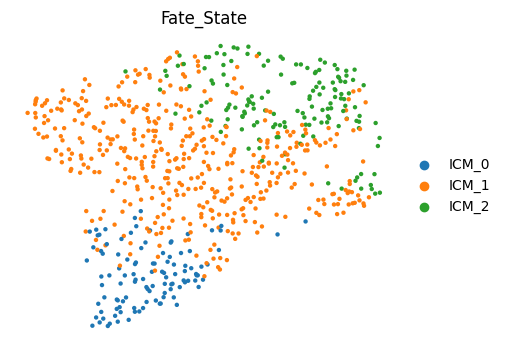

In [7]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.embedding(
        dmt.treedata.get_node('ICM',adata_object=True),
        basis='plt',
        color='Fate_State', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

/tmp/ipykernel_1530149/245439587.py:18: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)


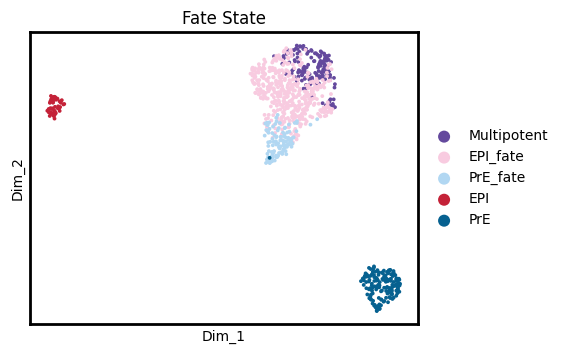

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import scanpy as sc
import anndata
import pandas as pd

adata_merged = anndata.concat(
    [dmt.treedata.get_node(cell,adata_object=True) for cell in dmt.treedata.nodes.keys()]
)
adata_to_plot = adata_merged.copy()

# rename DyMoTree Cell State
import pandas as pd
replacement_map = {'ICM_2': 'Multipotent', 'ICM_0': 'PrE_fate','ICM_1':'EPI_fate','EPI':'EPI','PrE':'PrE'}
new_order = ['Multipotent','EPI_fate','PrE_fate','EPI','PrE']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))

adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
new_order = ['Multipotent', 'EPI_fate', 'PrE_fate','EPI','PrE']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype('category')
new_order = ['ICM','EPI','PrE']
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))


color_map_state = {
    'PrE_fate': '#b1d7f2',
    'Multipotent': '#64499d',
    'EPI_fate': '#f8cbe0',
    'PrE':'#066190',
    'EPI':'#c42238'
}
state_color_list = [color_map_state[cat] for cat in adata_to_plot.obs['Fate_State'].cat.categories]
adata_to_plot.uns['Fate_State_colors'] = state_color_list

color_map_celltype = {
    'ICM': '#64499d',
    'PrE':'#066190',
    'EPI':'#c42238'
}
celltype_color_list = [color_map_celltype[cat] for cat in adata_to_plot.obs['lineage'].cat.categories]
adata_to_plot.uns['lineage_colors'] = celltype_color_list


with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_to_plot,
        x='Dim_1',
        y='Dim_2',
        color='Fate_State',  
        size=30,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

In [ ]:
dmt.save_model('./Fig3/dmt.pt')
adata_to_plot.write('./Fig3/mmE_dmt.h5ad')
dmt.tree_data.G.nodes['ICM']['data'].adata.write('./Fig3/ICM_dmt.h5ad')

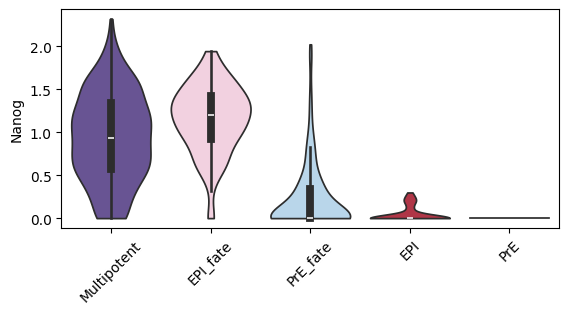

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

tree = sc.read('./Fig3/mmE_dmt.h5ad')
#stem = sc.read('D:/scRNA/mmEndoderm/Result.DyMoTree.10.14/ICM_dmt.h5ad')
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        tree,
        ['Nanog'],
        groupby='new_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig("./Fig3/mmE.nanog_expression.png",bbox_inches='tight')
    plt.show()

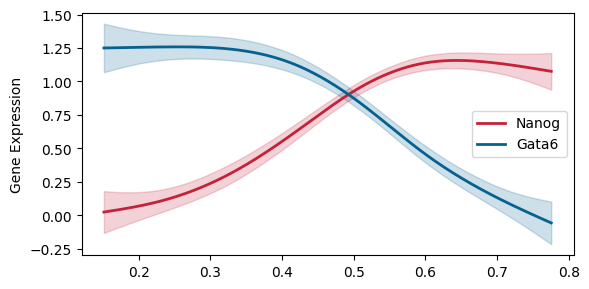

<Figure size 640x480 with 0 Axes>

In [25]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

stem = sc.read('./Fig3/ICM_dmt.h5ad')

from plotting import plot_feature_trend
features = ['Nanog','Gata6']
color_map = {features[0]:"#c42238",features[1]:"#066190"}

#features = ['Elane','Gfi1','Mpo']
#color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
ax = plot_feature_trend(stem,'fate',features,color_map,lin_space=1000,n_splines=10,lam=10,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(6, 3))
plt.savefig("./Fig3/mmE.EPI_PrE_marker_trends.pdf",bbox_inches='tight')
plt.show()

In [18]:
driver_result = dmt.find_driver(progenitor='ICM',
                top_n=100,
                soft_treshold=1,
                graph_threshold=0.,
                method='pearson',
                model='lasso',
                lasso_alpha=0.05
                )

/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[2026-06-08 11:03:37]Do regression
[2026-06-08 11:03:38] convolution by co-expression network


In [21]:
driver_result.sort_values(by='EPI_fate',ascending=False).head(30)

,EPI_fate,PrE_fate
Zfp42,0.001432,0.0
Fgf4,0.000832,0.0
Kdm5b,0.000798,0.0
Nanog,0.000786,0.0
Morc1,0.000748,0.0
Sox2,0.000724,0.0
Avpi1,0.000707,0.0
Tdgf1,0.000677,0.0
Klf2,0.000655,0.0
Rnf213,0.000613,0.0


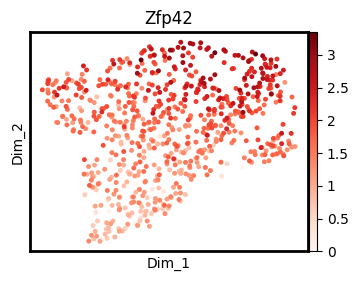

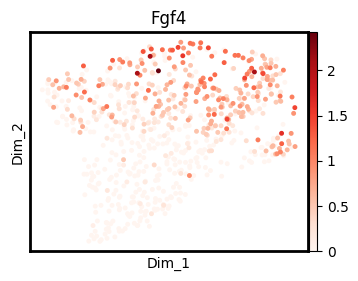

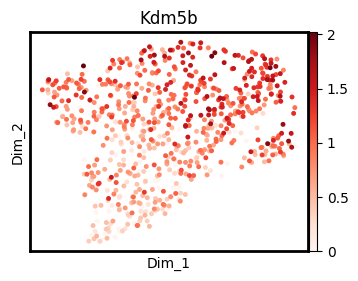

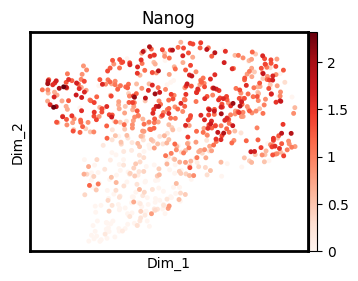

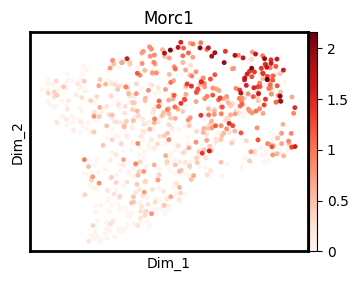

In [20]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

stem = sc.read('./Fig3/ICM_dmt.h5ad')
num_gene = 5
fate = 'EPI'
'''
gene = driver_result.coef.sort_values(by=fate,ascending=False).iloc[0:num_gene,:].index.tolist()
sc.pl.scatter(
            stem,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=50,
            color_map='Reds',
            frameon=False,
            show=True
        )
'''
for i in range(num_gene):
    gene = driver_result.coef.sort_values(by=fate,ascending=False).iloc[0:num_gene,:].index.tolist()[i]
    with rc_context({'figure.figsize': (4, 3)}):
        ax = sc.pl.scatter(
            stem,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=50,
            color_map='Reds',
            frameon=False,
            show=False
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        plt.savefig(f"./Fig3/mmE.{fate}_{gene}_featureplot.png",bbox_inches='tight')
        plt.show()

In [10]:
cospar_res = pd.read_csv('./Fig3/cospar_res.csv')
cospar_res = cospar_res[cospar_res['CellType'].isin(['ICM'])]
prob_values = cospar_res[['fate_map_transition_map_EPI', 'fate_map_transition_map_PrE']].values/cospar_res[['fate_map_transition_map_EPI', 'fate_map_transition_map_PrE']].values.sum(axis=1,keepdims=True)
stem.obs['Stemness_score_CoSpar'] = entropy(prob_values, axis=1, base=2)
stem.obs['development_time_CoSpar'] = 1-entropy(prob_values, axis=1, base=2)

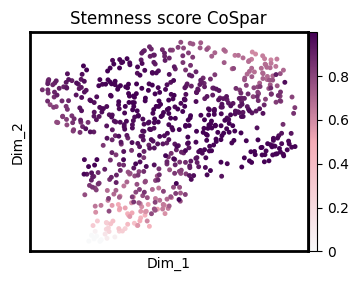

In [ ]:
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#f8f9fa"), (0.5,"#f4acb7"),(1,'#440154')]
)
metric = 'Stemness_score_CoSpar'
with rc_context({'figure.figsize': (4, 3)}):
    ax = sc.pl.scatter(
            stem,
            x='Dim_1',
            y='Dim_2',
            color=metric, 
            size=50,
            color_map=custom_bwr,
            frameon=False,
            show=False)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig(f"./Fig3/mmE.{metric}.pdf",bbox_inches='tight')
    plt.show()

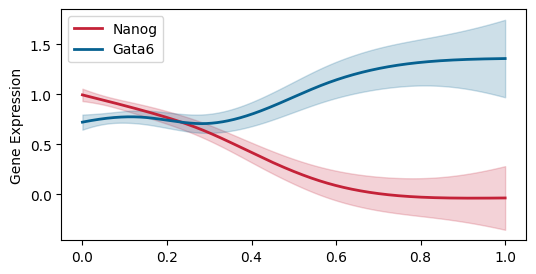

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
metric = 'development_time_CoSpar'
#stem = sc.read('./Fig3/ICM_dmt.h5ad')
from plotting import plot_feature_trend
features = ['Nanog','Gata6']
color_map = {features[0]:"#c42238",features[1]:"#066190"}

#features = ['Elane','Gfi1','Mpo']
#color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
ax = plot_feature_trend(stem,metric,features,color_map,lin_space=1000,n_splines=10,lam=10,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(6, 3),show=False)
#plt.savefig(f"./Fig3/ICM.Driver_trends.{metric}.pdf",bbox_inches='tight')
plt.show()

In [ ]:
# PrE 相关基因
genes_pre = driver_result.coef.sort_values(by='PrE',ascending=False).head(30).index.tolist()

# EPI 相关基因
genes_epi = driver_result.coef.sort_values(by='EPI',ascending=False).head(30).index.tolist()
import numpy as np
adata = dmt.tree_data.G.nodes['ICM']['data'].adata.copy()
# 按 fate_score 从低到高排序
adata_sorted = adata[adata.obs['fate'].argsort()].copy()
genes_all = genes_pre + genes_epi[::-1]
import scanpy as sc
adata_sorted.obs['all_cells'] = 'ICM'
sc.pl.heatmap(
    adata_sorted,
    var_names=genes_all,
    groupby='all_cells',
    swap_axes=True,        # 基因在 y 轴
    standard_scale="var",  # 强烈推荐
    show_gene_labels=True,
    cmap="Reds"         # 可选，默认也可以
)

In [ ]:
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

# ------------------
# gene class & colors
# ------------------
gene_class = {}
for g in genes_pre:
    gene_class[g] = 'pre'
for g in genes_epi:
    gene_class[g] = 'epi'

colors = {
    'pre': '#066190',   # PrE
    'epi': '#c42238'    # EPI
}
# ------------------
# x axis
# ------------------
x = adata.obs['fate'].values
x_grid = np.linspace(0, 1, 200)

# ------------------
# store class-level predictions
# ------------------
class_preds = {
    'pre': [],
    'epi': []
}

plt.figure(figsize=(6, 4))

# ------------------
# per-gene GAM fitting
# ------------------
for gene in genes_pre + genes_epi:
    y = adata[:, gene].X
    if hasattr(y, "toarray"):
        y = y.toarray().flatten()
    else:
        y = y.flatten()

    # gene-wise scaling
    y = StandardScaler().fit_transform(y[:, None]).flatten()

    gam = LinearGAM(s(0, n_splines=10)).fit(x[:, None], y)

    y_pred = gam.predict(x_grid)
    y_ci = gam.prediction_intervals(x_grid, width=0.95)

    cls = gene_class[gene]
    c = colors[cls]

    # store prediction for class-average curve
    class_preds[cls].append(y_pred)

    # 置信区间（最底层）
    plt.fill_between(
        x_grid,
        y_ci[:, 0],
        y_ci[:, 1],
        color=c,
        alpha=0.01,
        zorder=1
    )

    # 单基因趋势线（浅色，中层）
    plt.plot(
        x_grid,
        y_pred,
        color=c,
        alpha=0.1,
        linewidth=1,
        zorder=2
    )

# ------------------
# class-average curves（深色，最上层）
# ------------------
for cls in ['pre', 'epi']:
    mean_pred = np.mean(class_preds[cls], axis=0)
    plt.plot(
        x_grid,
        mean_pred,
        color=colors[cls],
        linewidth=3,
        alpha=1.0,
        zorder=5
    )

# ------------------
# legend
# ------------------
legend_elements = [
    Line2D([0], [0], color=colors['pre'], lw=3, label='PrE-biased genes'),
    Line2D([0], [0], color=colors['epi'], lw=3, label='EPI-biased genes')
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)


# ------------------
# labels & layout
# ------------------
plt.xlabel("Fate bias")
plt.ylabel("Gene expression")

plt.tight_layout()
plt.show()
